### 1. Préparation des données


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Téléchargement du dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=column_names, na_values='?')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Analyse Descriptive Détaillée
Nous allons examiner les statistiques de base de chaque colonne pour comprendre la distribution des données médicales.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


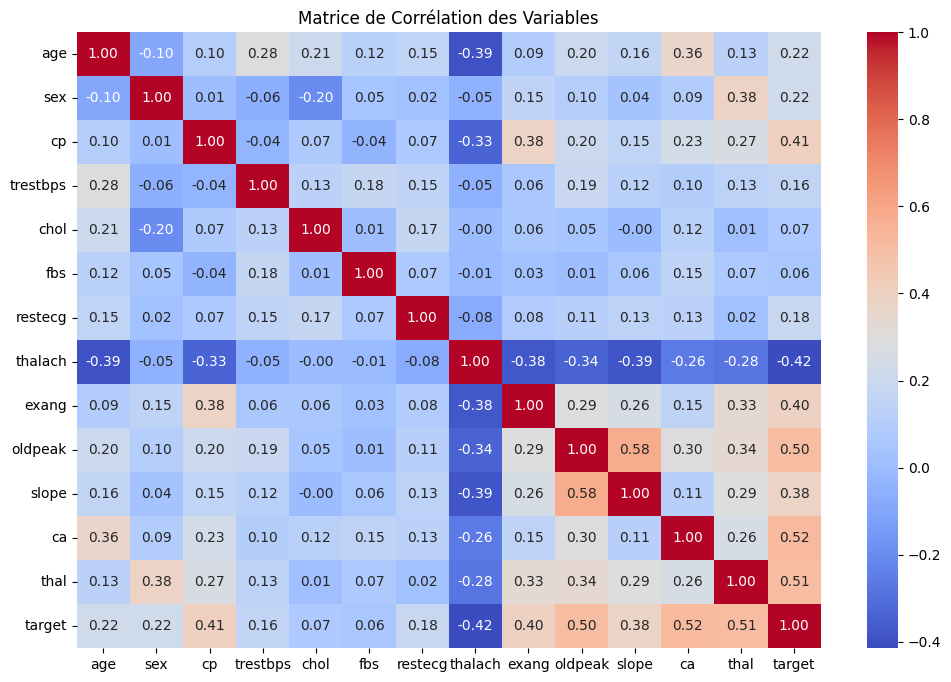

In [7]:
# Statistiques descriptives pour les variables numériques
display(df.describe())

# Matrice de corrélation pour voir les liens entre variables
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de Corrélation des Variables')
plt.show()

#### Interprétation de la Matrice de Corrélation :
- **Les carrés rouges/chauds** indiquent une corrélation positive : quand une variable augmente, l'autre a tendance à augmenter aussi (ex: `slope` et `oldpeak`).
- **Les carrés bleus/froids** indiquent une corrélation négative : quand une variable augmente, l'autre diminue (ex: `thalach` et `age`).
- **Proximité avec 1 ou -1** : Plus le chiffre est proche de 1 ou -1, plus le lien est fort. Ici, on voit que `cp`, `thalach`, `exang` et `oldpeak` sont les variables les plus liées à la cible (`target`).

### Visualisation des relations clés
Regardons l'impact de l'âge et du cholestérol sur la présence de maladies cardiaques.

/tmp/ipykernel_3121/1959432737.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='chol', data=df, palette='Set2')


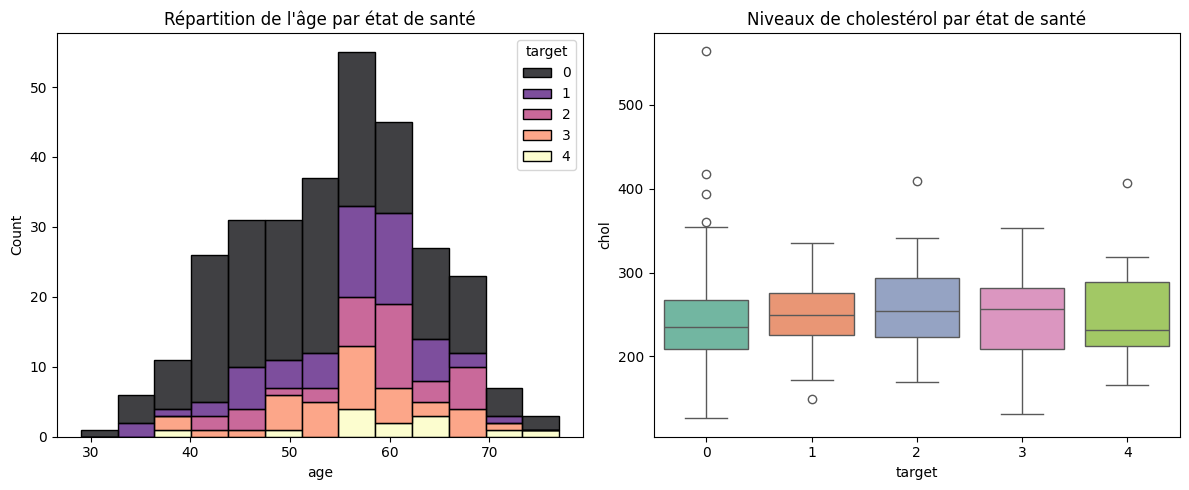

In [8]:
plt.figure(figsize=(12, 5))

# Âge vs Cible
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='target', multiple='stack', palette='magma')
plt.title('Répartition de l\'âge par état de santé')

# Cholestérol vs Cible
plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='chol', data=df, palette='Set2')
plt.title('Niveaux de cholestérol par état de santé')

plt.tight_layout()
plt.show()

#### Interprétation des Graphiques de Distribution :

1. **Âge vs État de santé** :
   - On observe que la fréquence des maladies cardiaques (en violet) augmente généralement avec l'âge, particulièrement après 50-60 ans.
   - Les patients plus jeunes ont une proportion plus élevée de résultats "Sains".

2. **Cholestérol vs État de santé** :
   - Le **boxplot** montre que la médiane du cholestérol est légèrement plus élevée chez les patients atteints de maladies cardiaques.
   - Les **points isolés** en haut du graphique sont des "outliers" (valeurs atypiques), comme le patient ayant un cholestérol supérieur à 500, ce qui est cliniquement exceptionnel.

### Analyse Exploratoire des Données (EDA)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Valeurs manquantes par colonne :
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        

/tmp/ipykernel_3121/2188728454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


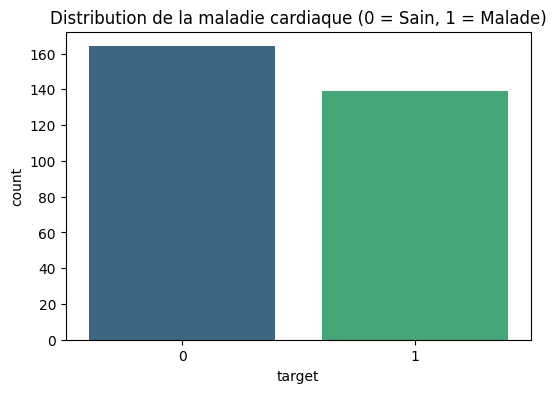

In [2]:
# Informations générales et valeurs manquantes
df.info()
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

# La cible originale est de 0 à 4. On la transforme en binaire (0: sain, 1: malade)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Visualisation de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution de la maladie cardiaque (0 = Sain, 1 = Malade)')
plt.show()

#### Interprétation de la Distribution de la Cible :
- **Équilibre des classes** : On observe que les deux barres (0 pour sain, 1 pour malade) sont de hauteurs assez proches.

### 2. Prétraitement et Entraînement du Modèle
Nous allons gérer les valeurs manquantes, normaliser les données et entraîner notre régression logistique.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Gestion des valeurs manquantes (remplacement par le mode)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# 2. Séparation des caractéristiques (X) et de la cible (y)
X = df.drop('target', axis=1)
y = df['target']

# 3. Division Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Mise à l'échelle des données (Scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Entraînement du modèle
model = LogisticRegression()
model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


### 3. Évaluation du Modèle
Voyons maintenant les performances de notre modèle sur les données de test.

Rapport de classification :
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



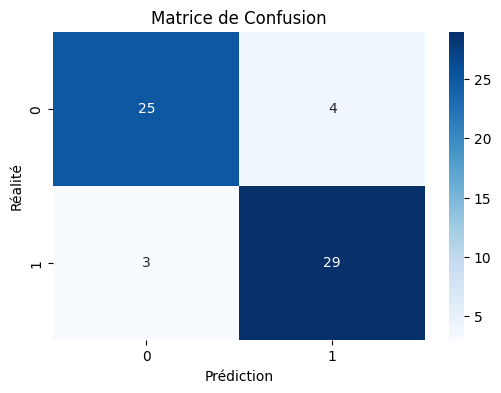

In [4]:
y_pred = model.predict(X_test)

# Rapport de classification
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

# Matrice de confusion
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.show()

#### Interprétation de la Matrice de Confusion :
- **Diagonale haut-gauche vers bas-droite** : Ce sont les prédictions correctes (Vrais Négatifs et Vrais Positifs). Plus ces chiffres sont élevés, meilleur est le modèle.
- **Les autres cases** : Ce sont les erreurs.
  - En haut à droite : Le modèle a prédit une maladie alors que le patient est sain.
  - En bas à gauche : Le modèle a dit que le patient était sain alors qu'il est malade (c'est l'erreur la plus grave en médecine).